Ali Hisham AlJamed 2240005868 7MA1/MA01

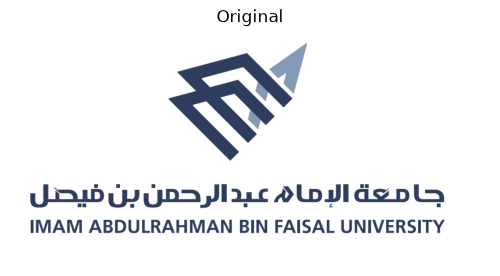

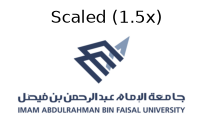

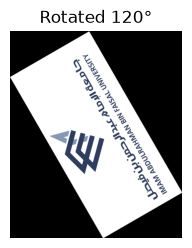

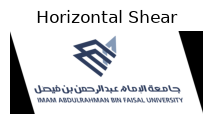

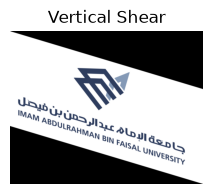

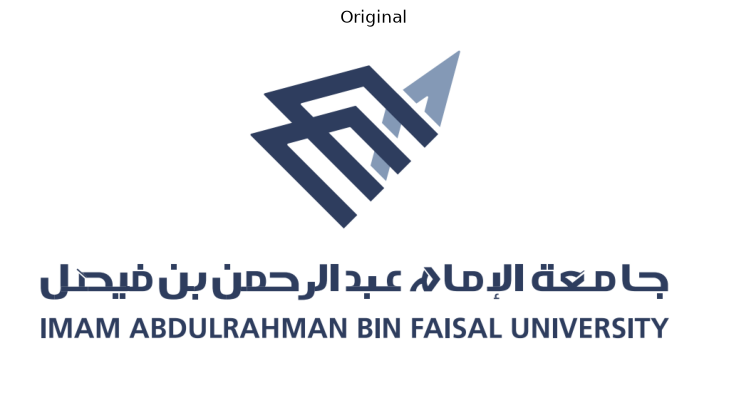

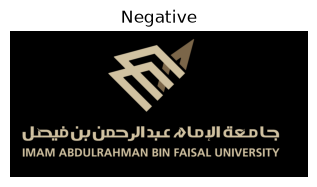

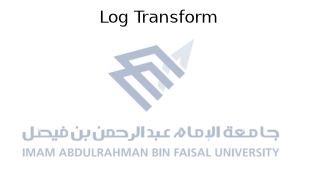

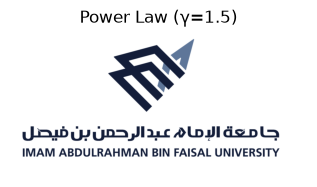

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load image ----------
img = cv2.imread("IAU_Logo.png")  
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# =========================================================
# TASK 1: Geometric Transformations
# =========================================================

# 1. Increase the size (scale by 1.5x)
scaled = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

# 2. Rotate by 120 degrees (expand canvas so nothing gets cropped)
center = (w / 2, h / 2)
M_rot = cv2.getRotationMatrix2D(center, 120, 1.0)
cos, sin = abs(M_rot[0, 0]), abs(M_rot[0, 1])
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)
M_rot[0, 2] += (new_w / 2) - center[0]
M_rot[1, 2] += (new_h / 2) - center[1]
rotated = cv2.warpAffine(img, M_rot, (new_w, new_h))

# 3. Shear (horizontal and vertical)
shear_x, shear_y = 0.3, 0.3

M_shear_h = np.float32([[1, shear_x, 0],
                        [0, 1,       0]])
sheared_h = cv2.warpAffine(img, M_shear_h, (int(w + h * shear_x), h))

M_shear_v = np.float32([[1,       0, 0],
                        [shear_y, 1, 0]])
sheared_v = cv2.warpAffine(img, M_shear_v, (w, int(h + w * shear_y)))

# =========================================================
# TASK 2: Intensity Transformations
# =========================================================

# 1. Negative image: s = 255 - r
negative = 255 - img

# 2. Log transformation: s = c * log(1 + r)
# c chosen so the maximum output maps to 255
img_float = img.astype(np.float32)
c = 255 / np.log(1 + np.max(img_float))
log_img = c * np.log(1 + img_float)
log_img = np.uint8(np.clip(log_img, 0, 255))

# 3. Power-law (gamma) transformation: s = c * r^gamma
# gamma > 1 darkens midtones and increases contrast in bright images
gamma = 1.5
normalized = img_float / 255.0
power_img = np.power(normalized, gamma)
power_img = np.uint8(np.clip(power_img * 255, 0, 255))

# =========================================================
# Display results
# =========================================================
def show(images, titles, rows, cols):
    plt.figure(figsize=(15, 8))
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(im)
        plt.title(t)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

# Task 1 results
show([img, scaled, rotated, sheared_h, sheared_v],["Original", "Scaled (1.5x)", "Rotated 120°", "Horizontal Shear", "Vertical Shear"],2, 3)

# Task 2 results
show([img, negative, log_img, power_img],["Original", "Negative", "Log Transform", f"Power Law (γ={gamma})"],2, 2)